# Transaction Monitoring Analysis

This notebook simulates a simplified transaction monitoring workflow across a portfolio of fictional banks.
**Structure:**
1. Data Generation: synthetic raw transactions
2. Data Quality Checks: identify and remove problematic rows
3. Data Compilation: aggregate the data to monthly level per bank
4. Data Visualisation: four charts
5. Analysis: final statistical insights


## Section 1: Data Generation

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

# Reproducibility: same synthetic data every time the notebook is run
np.random.seed(42)

In [ ]:
# Date range — full year 2025 (business days only)
START_DATE = pd.Timestamp("2025-01-01")
END_DATE   = pd.Timestamp("2025-12-31")
ALL_DATES  = pd.bdate_range(START_DATE, END_DATE)

# Number of banks per size category (fictional sizes)
# Large countries:  3 banks each (5 countries = 15 banks)
# Medium countries: 2 banks each (4 countries =  8 banks)
# Smaller countries: 1 bank each (11 countries = 11 banks)
N_BANKS_LARGE  = 5 * 3   # 15 banks
N_BANKS_MEDIUM = 4 * 2   #  8 banks
N_BANKS_SMALL  = 11 * 1  # 11 banks
TOTAL_BANKS    = N_BANKS_LARGE + N_BANKS_MEDIUM + N_BANKS_SMALL

# Naming the banks as BANK_XX
BANK_NAMES = [f"BANK_{i:02d}" for i in range(1, TOTAL_BANKS + 1)]

# Instrument types: generic labels
INSTRUMENT_TYPES = ["TYPE_A", "TYPE_B", "TYPE_C", "TYPE_D"]

# Price range per instrument type
PRICE_RANGES = {
    "TYPE_A": (1, 100),
    "TYPE_B": (10, 500),
    "TYPE_C": (50, 1_000),
    "TYPE_D": (100, 5_000),
}

# Bank trading profiles
# large: few trades, very high amounts (e.g. wholesale bank)
# frequent: many trades, small amounts (e.g. high-frequency trader)
# normal: balanced activity
BANK_PROFILES = {}
for i, bank in enumerate(BANK_NAMES):
    if i in [0, 1, 2]:
        BANK_PROFILES[bank] = "large"
    elif i in [3, 4, 5]:
        BANK_PROFILES[bank] = "frequent"
    else:
        BANK_PROFILES[bank] = "normal"

print(f"Total banks: {len(BANK_NAMES)}")
print("\nBank profiles:")
for bank, profile in BANK_PROFILES.items():
    print(f"  {bank}: {profile}")

Total banks: 34

Bank profiles:
  BANK_01: large
  BANK_02: large
  BANK_03: large
  BANK_04: frequent
  BANK_05: frequent
  BANK_06: frequent
  BANK_07: normal
  BANK_08: normal
  BANK_09: normal
  BANK_10: normal
  BANK_11: normal
  BANK_12: normal
  BANK_13: normal
  BANK_14: normal
  BANK_15: normal
  BANK_16: normal
  BANK_17: normal
  BANK_18: normal
  BANK_19: normal
  BANK_20: normal
  BANK_21: normal
  BANK_22: normal
  BANK_23: normal
  BANK_24: normal
  BANK_25: normal
  BANK_26: normal
  BANK_27: normal
  BANK_28: normal
  BANK_29: normal
  BANK_30: normal
  BANK_31: normal
  BANK_32: normal
  BANK_33: normal
  BANK_34: normal


In [29]:
def generate_transactions(n_transactions: int = 200_000) -> pd.DataFrame:
    """
    Generate a synthetic dataset of raw transactions.

    Each row represents one transaction where:
    - The bank is always the BUYER
    - The counterparty is always the SELLER
    - A bank cannot trade with itself
    - Banks have uneven activity levels and different trading profiles:
        - large: few trades, very high amounts
        - frequent: many trades, small amounts
        - normal: balanced activity
    - AMOUNT_EUR = QUANTITY x PRICE_EUR

    Parameters
    ----------
    n_transactions : int
        Number of transactions to generate (default 200,000)

    Returns
    -------
    pd.DataFrame
        Raw transaction dataset with deliberate data quality issues injected.
    """

    n_banks = len(BANK_NAMES)

    # Assign uneven activity weights using exponential distribution
    raw_weights = np.random.exponential(scale=1.0, size=n_banks)
    activity_weights = raw_weights / raw_weights.sum()

    # Adjust weights by profile
    for i, bank in enumerate(BANK_NAMES):
        if BANK_PROFILES[bank] == "frequent":
            activity_weights[i] *= 3.0 # trade much more often
        elif BANK_PROFILES[bank] == "large":
            activity_weights[i] *= 0.3 # trade much less often

    # Renormalise again after adjustment
    activity_weights = activity_weights / activity_weights.sum()

    # Sample buyer banks according to activity weights
    buyer_indices = np.random.choice(n_banks, size=n_transactions, p=activity_weights)

    # For each buyer, sample a counterparty (cannot be the same bank)
    seller_indices = np.array([
        np.random.choice([j for j in range(n_banks) if j != buyer_indices[i]])
        for i in range(n_transactions)
    ])

    # Random dates from business days
    date_indices = np.random.randint(0, len(ALL_DATES), n_transactions)

    # Random instrument types
    instrument_types = np.random.choice(INSTRUMENT_TYPES, n_transactions)

    # Quantity varies by bank profile
    quantities = np.array([
        np.random.randint(500_000, 1_000_000) if BANK_PROFILES[BANK_NAMES[buyer_indices[i]]] == "large"
        else np.random.randint(10, 500) if BANK_PROFILES[BANK_NAMES[buyer_indices[i]]] == "frequent"
        else np.random.randint(100, 100_000)
        for i in range(n_transactions)
    ], dtype=float)

    # Price varies by instrument type
    prices = np.array([
        np.random.uniform(*PRICE_RANGES[inst])
        for inst in instrument_types
    ]).round(4)

    # Amount calculation and TRADE_ID generation 
    amounts   = (quantities * prices).round(2)
    trade_ids = [f"TRD_{i:08d}" for i in range(n_transactions)]

    df = pd.DataFrame({
        "TRADE_ID":        trade_ids,
        "DATE":            ALL_DATES[date_indices],
        "BANK":            [BANK_NAMES[i] for i in buyer_indices],
        "INSTRUMENT_TYPE": instrument_types,
        "COUNTERPARTY":    [BANK_NAMES[i] for i in seller_indices],
        "SIDE":            "Buy",
        "QUANTITY":        quantities,
        "PRICE_EUR":       prices,
        "AMOUNT_EUR":      amounts,
    })

    # ----------------------------------------------------------
    # Inject deliberate data quality issues
    # ----------------------------------------------------------

    # Issue 1: 50 rows with null price (simulating a price feed failure)
    null_idx = np.random.choice(df.index, 50, replace=False)
    df.loc[null_idx, "PRICE_EUR"] = np.nan

    # Issue 2: 30 duplicate trade IDs (simulating double submission)
    dup_idx = np.random.choice(df.index[1:], 30, replace=False)
    df.loc[dup_idx, "TRADE_ID"] = df.loc[dup_idx - 1, "TRADE_ID"].values

    # Issue 3: 20 rows with negative amount (simulating a data entry error)
    neg_idx = np.random.choice(df.index, 20, replace=False)
    df.loc[neg_idx, "AMOUNT_EUR"] = -df.loc[neg_idx, "AMOUNT_EUR"]

    # Issue 4: 10 rows where amount != quantity x price (calculation error)
    calc_idx = np.random.choice(df.index, 10, replace=False)
    df.loc[calc_idx, "AMOUNT_EUR"] = (df.loc[calc_idx, "AMOUNT_EUR"] * 1.5).round(2)

    return df


# Generate the dataset
df_raw = generate_transactions()
print(f"Dataset generated: {len(df_raw):,} transactions")
print(f"Date range: {df_raw['DATE'].min().date()} to {df_raw['DATE'].max().date()}")
df_raw.head(10)

Dataset generated: 200,000 transactions
Date range: 2025-01-01 to 2025-12-31


,TRADE_ID,DATE,BANK,INSTRUMENT_TYPE,COUNTERPARTY,SIDE,QUANTITY,PRICE_EUR,AMOUNT_EUR
0,TRD_00000000,2025-07-10,BANK_34,TYPE_D,BANK_04,Buy,59121.0,2522.8627,1.491542e+08
1,TRD_00000001,2025-11-27,BANK_28,TYPE_D,BANK_01,Buy,82729.0,1338.6981,1.107492e+08
2,TRD_00000002,2025-04-18,BANK_10,TYPE_C,BANK_26,Buy,18729.0,986.3216,1.847282e+07
3,TRD_00000003,2025-12-08,BANK_04,TYPE_B,BANK_06,Buy,93.0,335.7040,3.122047e+04
4,TRD_00000004,2025-11-28,BANK_23,TYPE_B,BANK_18,Buy,72079.0,321.7999,2.319501e+07
5,TRD_00000005,2025-08-20,BANK_12,TYPE_A,BANK_13,Buy,31769.0,46.5143,1.477713e+06
6,TRD_00000006,2025-12-18,BANK_04,TYPE_D,BANK_15,Buy,331.0,4741.9686,1.569592e+06
7,TRD_00000007,2025-05-23,BANK_13,TYPE_A,BANK_15,Buy,64527.0,95.8628,6.185739e+06
8,TRD_00000008,2025-11-17,BANK_02,TYPE_B,BANK_10,Buy,515306.0,107.6308,5.546280e+07
9,TRD_00000009,2025-06-18,BANK_34,TYPE_A,BANK_04,Buy,34260.0,95.7688,3.281039e+06


## Section 2: Data Quality Checks

Before cleaning, we first explore the raw dataset to understand the data and its structure.
Then we run five checks, remove problematic rows, and show again the results.

### 2.1: Data Overview (before cleaning)

In [ ]:
def exploratory_summary(df: pd.DataFrame, label: str = "RAW DATA") -> None:
    """
    Print a summary of the dataset.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset to summarise
    label : str
        Label shown in the header
    """
    print("-" * 55)
    print(f"  EXPLORATORY SUMMARY - {label}")
    print("-" * 55)

    print(f"Total rows:              {len(df):>10,}")
    print(f"Unique banks:            {df['BANK'].nunique():>10,}")
    print(f"Unique counterparties:   {df['COUNTERPARTY'].nunique():>10,}")
    print(f"Unique instrument types: {df['INSTRUMENT_TYPE'].nunique():>10,}")
    print(f"Date range:              {df['DATE'].min().date()} to {df['DATE'].max().date()}")

    print("\n--- Transactions by Instrument Type ---")
    print(df["INSTRUMENT_TYPE"].value_counts().to_string())

    print("\n--- Transactions by Bank (activity distribution) ---")
    print(df["BANK"].value_counts().to_string())

    print("\n--- Amount (EUR) Statistics ---")
    print(df["AMOUNT_EUR"].describe().round(2).to_string())

    print("-" * 55)


exploratory_summary(df_raw, label="RAW DATA")

-------------------------------------------------------
  EXPLORATORY SUMMARY - RAW DATA
-------------------------------------------------------
Total rows:                 200,000
Unique banks:                    34
Unique counterparties:           34
Unique instrument types:          4
Date range:              2025-01-01 to 2025-12-31

--- Transactions by Instrument Type ---
INSTRUMENT_TYPE
TYPE_A    50210
TYPE_C    50113
TYPE_D    49899
TYPE_B    49778

--- Transactions by Bank (activity distribution) ---
BANK
BANK_12    25371
BANK_34    21534
BANK_04    19955
BANK_08    14657
BANK_13    13024
BANK_26    11127
BANK_10     9077
BANK_21     6982
BANK_31     6926
BANK_29     6574
BANK_09     6541
BANK_02     6419
BANK_18     5433
BANK_28     5253
BANK_25     4526
BANK_19     4079
BANK_05     3755
BANK_06     3709
BANK_24     3291
BANK_03     2903
BANK_17     2600
BANK_20     2545
BANK_23     2508
BANK_14     1701
BANK_27     1613
BANK_16     1523
BANK_15     1466
BANK_32     1400
BANK_

### 2.2: Quality Checks and Cleaning

In [40]:
def run_quality_checks(df: pd.DataFrame) -> pd.DataFrame:
    """
    Run a series of data quality checks on the raw transaction dataset.

    Checks performed:
    1. Weekend transactions
    2. Missing values
    3. Duplicate trade IDs
    4. Negative or zero amount / price / quantity
    5. Sanity check: amount == quantity x price

    Each issue is reported and problematic rows are removed.
    In the end, returns the cleaned DataFrame.
    """
    print("-" * 55)
    print("  DATA QUALITY CHECKS")
    print("-" * 55)

    rows_start = len(df)
    df = df.copy()

    # ----------------------------------------------------------
    # Check 1: Weekend transactions
    # ----------------------------------------------------------
    weekends   = df["DATE"].dt.dayofweek >= 5
    n_weekends = weekends.sum()
    if n_weekends > 0:
        print(f"WARNING - Weekend transactions: {n_weekends} rows found - removing affected rows.")
        df = df[~weekends]
    else:
        print("CHECK 1 PASSED - No transactions on weekends.")

    # ----------------------------------------------------------
    # Check 2: Missing values
    # ----------------------------------------------------------
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if not missing.empty:
        print(f"\nWARNING - Missing values found:")
        for col, n in missing.items():
            print(f"  {col}: {n} null values - removing affected rows.")
        df = df.dropna()
    else:
        print("CHECK 2 PASSED - No missing values.")

    # ----------------------------------------------------------
    # Check 3: Duplicate trade IDs
    # ----------------------------------------------------------
    duplicates = df.duplicated(subset=["TRADE_ID"])
    n_dupes    = duplicates.sum()
    if n_dupes > 0:
        print(f"\nWARNING - Duplicate trade IDs: {n_dupes} found - removing affected rows.")
        df = df[~duplicates]
    else:
        print("CHECK 3 PASSED - No duplicate trade IDs.")

    # ----------------------------------------------------------
    # Check 4: Negative or zero values
    # ----------------------------------------------------------
    invalid   = (df["AMOUNT_EUR"] <= 0) | (df["PRICE_EUR"] <= 0) | (df["QUANTITY"] <= 0)
    n_invalid = invalid.sum()
    if n_invalid > 0:
        print(f"\nWARNING - Negative or zero values: {n_invalid} rows found - removing affected rows.")
        df = df[~invalid]
    else:
        print("CHECK 4 PASSED - No negative or zero values.")

    # ----------------------------------------------------------
    # Check 5: Sanity check — amount == quantity x price
    # ----------------------------------------------------------
    tolerance       = 0.01
    expected_amount = (df["QUANTITY"] * df["PRICE_EUR"]).round(2)
    mismatch        = (df["AMOUNT_EUR"] - expected_amount).abs() > tolerance
    n_mismatch      = mismatch.sum()
    if n_mismatch > 0:
        print(f"\nWARNING - Amount mismatch: {n_mismatch} rows where AMOUNT_EUR != QUANTITY x PRICE_EUR - removing affected rows.")
        df = df[~mismatch]
    else:
        print("CHECK 5 PASSED - All amounts consistent with quantity x price.")

    # ----------------------------------------------------------
    # Summary
    # ----------------------------------------------------------
    rows_end = len(df)
    print(f"\nRows before cleaning: {rows_start:,}")
    print(f"Rows after cleaning:  {rows_end:,}")
    print(f"Rows removed:         {rows_start - rows_end:,}")
    print("-" * 55)

    return df.reset_index(drop=True)


df_clean = run_quality_checks(df_raw)

-------------------------------------------------------
  DATA QUALITY CHECKS
-------------------------------------------------------
CHECK 1 PASSED - No transactions on weekends.

WARNING - Missing values found:
  PRICE_EUR: 50 null values - removing affected rows.

WARNING - Duplicate trade IDs: 30 found - removing affected rows.

WARNING - Negative or zero values: 20 rows found - removing affected rows.

WARNING - Amount mismatch: 10 rows where AMOUNT_EUR != QUANTITY x PRICE_EUR - removing affected rows.

Rows before cleaning: 200,000
Rows after cleaning:  199,890
Rows removed:         110
-------------------------------------------------------


### 2.3: Data Overview (after cleaning)

In [32]:
exploratory_summary(df_clean, label="CLEAN DATA")

-------------------------------------------------------
  EXPLORATORY SUMMARY - CLEAN DATA
-------------------------------------------------------
Total rows:                 199,890
Unique banks:                    34
Unique counterparties:           34
Unique instrument types:          4
Date range:              2025-01-01 to 2025-12-31

--- Transactions by Instrument Type ---
INSTRUMENT_TYPE
TYPE_A    50186
TYPE_C    50083
TYPE_D    49868
TYPE_B    49753

--- Transactions by Bank (activity distribution) ---
BANK
BANK_12    25353
BANK_34    21524
BANK_04    19946
BANK_08    14649
BANK_13    13016
BANK_26    11118
BANK_10     9075
BANK_21     6978
BANK_31     6921
BANK_29     6572
BANK_09     6538
BANK_02     6414
BANK_18     5428
BANK_28     5251
BANK_25     4526
BANK_19     4076
BANK_05     3754
BANK_06     3707
BANK_24     3288
BANK_03     2902
BANK_17     2599
BANK_20     2544
BANK_23     2507
BANK_14     1699
BANK_27     1612
BANK_16     1521
BANK_15     1466
BANK_32     1400
BAN

## Section 3: Data Compilation

Aggregate the clean transaction-level data to a monthly summary per bank.
Each row in the compiled dataset represents one bank per each month.

Derived columns (per one month):
- TOTAL_AMOUNT_EUR: total traded amount
- TRADE_COUNT: number of trades
- UNIQUE_COUNTERPARTIES: number of distinct counterparties
- TOP_INSTRUMENT_TYPE: most frequently traded instrument type
- MOM_CHANGE_PCT: month-over-month percentage change in total amount traded

In [ ]:
def compile_monthly(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate clean transaction data to monthly level per bank.

    For each bank and month, computes:
    - TOTAL_AMOUNT_EUR: sum of all traded amounts
    - TRADE_COUNT: number of trades executed
    - UNIQUE_COUNTERPARTIES: number of distinct counterparties traded with
    - TOP_INSTRUMENT_TYPE: most frequently traded instrument type
    - MOM_CHANGE_PCT: month-over-month % change in total amount

    Parameters
    ----------
    df : pd.DataFrame
        Clean transaction-level dataset

    Returns
    -------
    pd.DataFrame
        Monthly summary with one row per bank per month
    """

    df = df.copy()
    df["MONTH"] = df["DATE"].dt.to_period("M")

    # Most traded instrument type per bank per month
    top_instrument = (
        df.groupby(["BANK", "MONTH", "INSTRUMENT_TYPE"])
        .size()
        .reset_index(name="COUNT")
        .sort_values("COUNT", ascending=False)
        .drop_duplicates(subset=["BANK", "MONTH"])
        [["BANK", "MONTH", "INSTRUMENT_TYPE"]]
        .rename(columns={"INSTRUMENT_TYPE": "TOP_INSTRUMENT_TYPE"})
    )

    # Aggregations
    monthly = (
        df.groupby(["BANK", "MONTH"])
        .agg(
            TOTAL_AMOUNT_EUR = ("AMOUNT_EUR",   "sum"),
            TRADE_COUNT = ("TRADE_ID",     "count"),
            UNIQUE_COUNTERPARTIES = ("COUNTERPARTY", "nunique"),
        )
        .reset_index()
    )

    # Merge to the top instrument type
    monthly = monthly.merge(top_instrument, on=["BANK", "MONTH"], how="left")

    # Sort before computing month-over-month change
    monthly = monthly.sort_values(["BANK", "MONTH"]).reset_index(drop=True)

    # Month-over-month % change in total amount per bank
    monthly["MOM_CHANGE_PCT"] = (
        monthly.groupby("BANK")["TOTAL_AMOUNT_EUR"]
        .pct_change() * 100
    ).round(2)

    monthly["TOTAL_AMOUNT_EUR"] = monthly["TOTAL_AMOUNT_EUR"].round(2)

    return monthly


df_monthly = compile_monthly(df_clean)

print(f"Monthly dataset compiled: {len(df_monthly):,} rows")
print(f"Banks: {df_monthly['BANK'].nunique()} | Months: {df_monthly['MONTH'].nunique()}")
df_monthly.head(20)

Monthly dataset compiled: 408 rows
Banks: 34 | Months: 12


,BANK,MONTH,TOTAL_AMOUNT_EUR,TRADE_COUNT,UNIQUE_COUNTERPARTIES,TOP_INSTRUMENT_TYPE,MOM_CHANGE_PCT
0,BANK_01,2025-01,6.003424e+10,94,30,TYPE_C,NaN
1,BANK_01,2025-02,4.136211e+10,70,29,TYPE_A,-31.10
2,BANK_01,2025-03,6.666940e+10,91,31,TYPE_D,61.18
3,BANK_01,2025-04,4.741338e+10,82,30,TYPE_A,-28.88
4,BANK_01,2025-05,5.394917e+10,80,29,TYPE_C,13.78
5,BANK_01,2025-06,5.059775e+10,81,31,TYPE_D,-6.21
6,BANK_01,2025-07,6.333493e+10,89,30,TYPE_B,25.17
7,BANK_01,2025-08,4.042030e+10,87,31,TYPE_B,-36.18
8,BANK_01,2025-09,6.285418e+10,85,32,TYPE_C,55.50
9,BANK_01,2025-10,5.461804e+10,79,31,TYPE_C,-13.10


## Section 4: Data Visualisation

Four charts created from the compiled dataset:
1. Monthly trading activity (amount + trade count) for the top 5 most active banks
2. Scatter plot — trading amount vs frequency for all banks
3. Counterparty network heatmap — number of trades between bank pairs (top 10 banks)
4. Month-over-month volatility heatmap (top 10 banks)

In [54]:
# ECB brand colours
BLACK           = "#000000"
ECB_BLUE        = "#003299"
ECB_YELLOW      = "#FFB400"
ECB_RED         = "#FF4B00"
ECB_LIGHT_GREEN = "#65B800"
ECB_CYAN        = "#00B1EA"
ECB_LIGHT       = "#F0F5FF"

# Shared figure style
plt.rcParams.update({
    "figure.facecolor": ECB_LIGHT,
    "axes.facecolor":   ECB_LIGHT,
    "axes.edgecolor":   BLACK,
    "axes.labelcolor":  BLACK,
    "xtick.color":      BLACK,
    "ytick.color":      BLACK,
    "text.color":       BLACK,
    "axes.titleweight": "bold",
    "axes.titlecolor":  ECB_BLUE,
})

### Chart 1: Monthly Trading Activity - Top 5 Most Active Banks

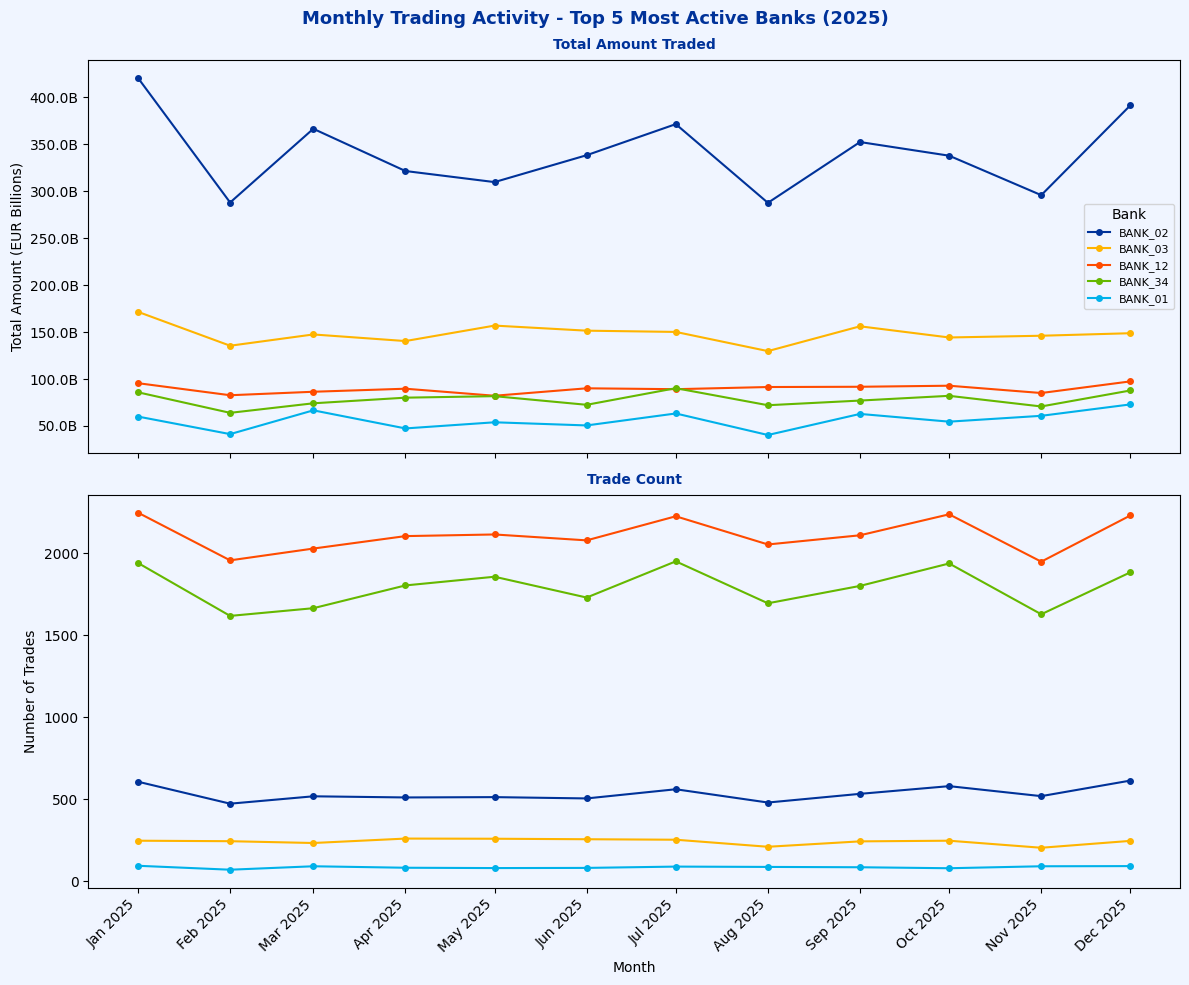

Chart saved: chart1_activity.png


In [69]:
# Number of top banks to display
N_TOP_BANKS = 5 #change this value to show more or fewer banks

# Identify the top N most active banks by total amount (10 now for readability)
top_banks = (
    df_monthly.groupby("BANK")["TOTAL_AMOUNT_EUR"]
    .sum()
    .nlargest(N_TOP_BANKS)
    .index.tolist()
)

# Filter monthly data for top banks only
df_top = df_monthly[df_monthly["BANK"].isin(top_banks)].copy()
df_top["MONTH_DT"] = df_top["MONTH"].dt.to_timestamp()

# Two panels sharing the same X axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
fig.suptitle(
    f"Monthly Trading Activity - Top {N_TOP_BANKS} Most Active Banks (2025)",
    fontsize=13, fontweight="bold", color=ECB_BLUE
)

# One distinct colour per bank using the palette above
bank_colours = [
    ECB_BLUE,
    ECB_YELLOW,
    ECB_RED,
    ECB_LIGHT_GREEN,
    ECB_CYAN,
]

for bank, color in zip(top_banks, bank_colours):
    bank_data = df_top[df_top["BANK"] == bank].sort_values("MONTH_DT")

    # Top panel: total amount traded
    ax1.plot(
        bank_data["MONTH_DT"],
        bank_data["TOTAL_AMOUNT_EUR"] / 1e9,
        marker="o", markersize=4, linewidth=1.5,
        label=bank, color=color,
    )

    # Bottom panel: number of trades
    ax2.plot(
        bank_data["MONTH_DT"],
        bank_data["TRADE_COUNT"],
        marker="o", markersize=4, linewidth=1.5,
        label=bank, color=color,
    )

# Top panel formatting
ax1.set_ylabel("Total Amount (EUR Billions)", color=BLACK)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}B"))
ax1.legend(title="Bank", fontsize=8)
ax1.set_title("Total Amount Traded", fontsize=10, pad=8)

# Bottom panel formatting
ax2.set_ylabel("Number of Trades", color=BLACK)
ax2.set_xlabel("Month", color=BLACK)
ax2.set_title("Trade Count", fontsize=10, pad=8)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig("chart1_activity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: chart1_activity.png")

### Chart 2: Trading Amount vs Frequency - All Banks

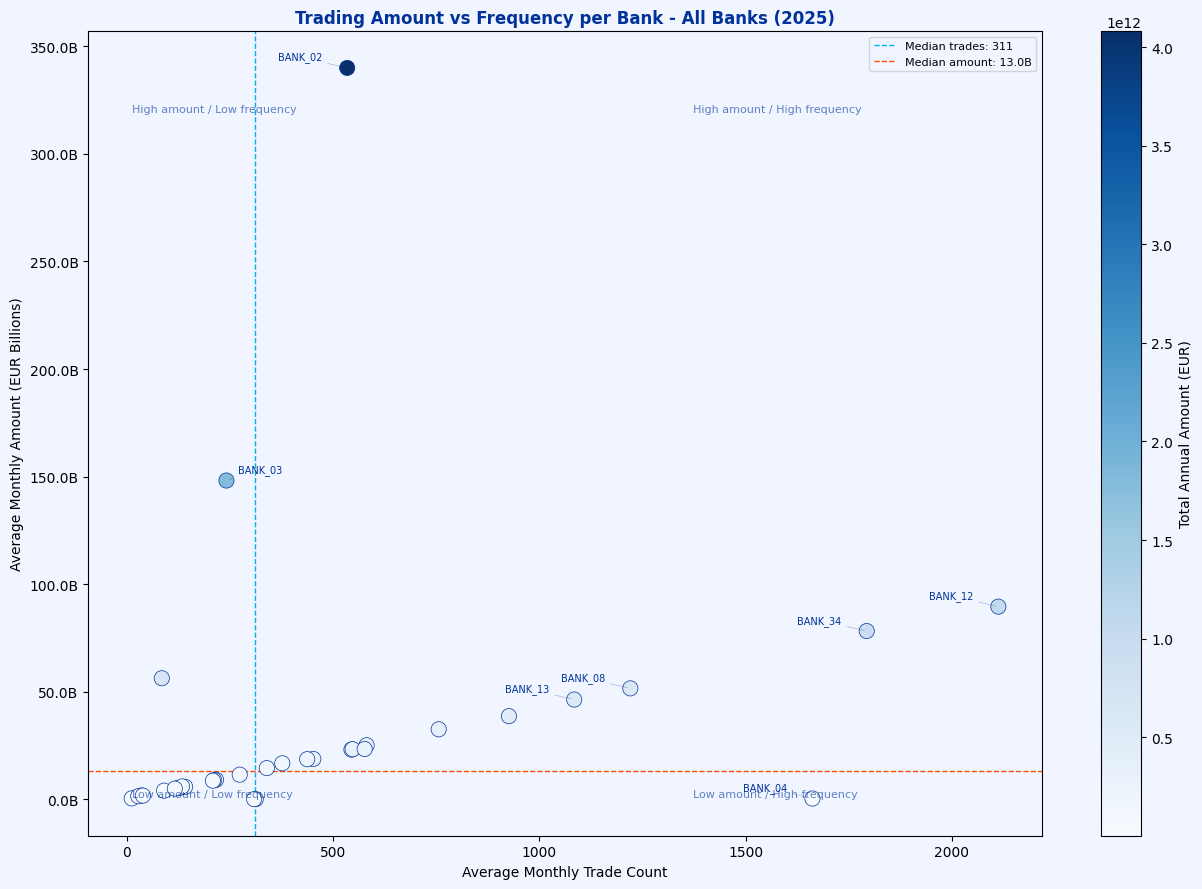

Chart saved: chart2_scatter.png


In [ ]:
# Aggregate full year averages per bank
scatter_data = (
    df_monthly.groupby("BANK")
    .agg(
        AVG_MONTHLY_AMOUNT = ("TOTAL_AMOUNT_EUR", "mean"),
        AVG_MONTHLY_TRADES = ("TRADE_COUNT", "mean"),
        TOTAL_AMOUNT = ("TOTAL_AMOUNT_EUR", "sum"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 9))

scatter = ax.scatter(
    scatter_data["AVG_MONTHLY_TRADES"],
    scatter_data["AVG_MONTHLY_AMOUNT"] / 1e9,
    c=scatter_data["TOTAL_AMOUNT"],
    cmap="Blues",
    s=120,
    edgecolors=ECB_BLUE,
    linewidths=0.5,
    zorder=3,
)

# Only label banks that stand out — more than 1 std dev from mean
# in either amount or trade count dimension
# Done to avoid labelling everything in the cluster (for readability)
mean_amount = scatter_data["AVG_MONTHLY_AMOUNT"].mean()
std_amount  = scatter_data["AVG_MONTHLY_AMOUNT"].std()
mean_trades = scatter_data["AVG_MONTHLY_TRADES"].mean()
std_trades  = scatter_data["AVG_MONTHLY_TRADES"].std()

banks_to_label = set(
    scatter_data[
        (scatter_data["AVG_MONTHLY_AMOUNT"] > mean_amount + std_amount) |
        (scatter_data["AVG_MONTHLY_AMOUNT"] < mean_amount - std_amount) |
        (scatter_data["AVG_MONTHLY_TRADES"] > mean_trades + std_trades) |
        (scatter_data["AVG_MONTHLY_TRADES"] < mean_trades - std_trades)
    ]["BANK"].tolist()
)

for _, row in scatter_data.iterrows():
    if row["BANK"] not in banks_to_label:
        continue

    x = row["AVG_MONTHLY_TRADES"]
    y = row["AVG_MONTHLY_AMOUNT"] / 1e9

    x_offset = 8 if x < scatter_data["AVG_MONTHLY_TRADES"].median() else -50
    y_offset  = 6

    ax.annotate(
        row["BANK"],
        (x, y),
        fontsize=7,
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        color=ECB_BLUE,
        arrowprops=dict(arrowstyle="-", color=ECB_BLUE, alpha=0.3, lw=0.5),
    )

# Quadrant reference lines, colour palette above
median_trades = scatter_data["AVG_MONTHLY_TRADES"].median()
median_amount = (scatter_data["AVG_MONTHLY_AMOUNT"] / 1e9).median()

ax.axvline(median_trades, color=ECB_CYAN, linestyle="--",
           linewidth=1, label=f"Median trades: {median_trades:.0f}")
ax.axhline(median_amount, color=ECB_RED, linestyle="--",
           linewidth=1, label=f"Median amount: {median_amount:.1f}B")

# Quadrant labels
x_min = scatter_data["AVG_MONTHLY_TRADES"].min()
x_max = scatter_data["AVG_MONTHLY_TRADES"].max()
y_min = (scatter_data["AVG_MONTHLY_AMOUNT"] / 1e9).min()
y_max = (scatter_data["AVG_MONTHLY_AMOUNT"] / 1e9).max()

ax.text(x_min, y_max * 0.95, "High amount / Low frequency",
        fontsize=8, color=ECB_BLUE, alpha=0.6, va="top")
ax.text(x_max * 0.65, y_max * 0.95, "High amount / High frequency",
        fontsize=8, color=ECB_BLUE, alpha=0.6, va="top")
ax.text(x_min, y_min * 2.5, "Low amount / Low frequency",
        fontsize=8, color=ECB_BLUE, alpha=0.6, va="bottom")
ax.text(x_max * 0.65, y_min * 2.5, "Low amount / High frequency",
        fontsize=8, color=ECB_BLUE, alpha=0.6, va="bottom")

plt.colorbar(scatter, ax=ax, label="Total Annual Amount (EUR)")
ax.set_xlabel("Average Monthly Trade Count", color=BLACK)
ax.set_ylabel("Average Monthly Amount (EUR Billions)", color=BLACK)
ax.set_title("Trading Amount vs Frequency per Bank - All Banks (2025)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}B"))
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("chart2_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: chart2_scatter.png")

### Chart 3: Counterparty Network - Trade Volume Between Bank Pairs

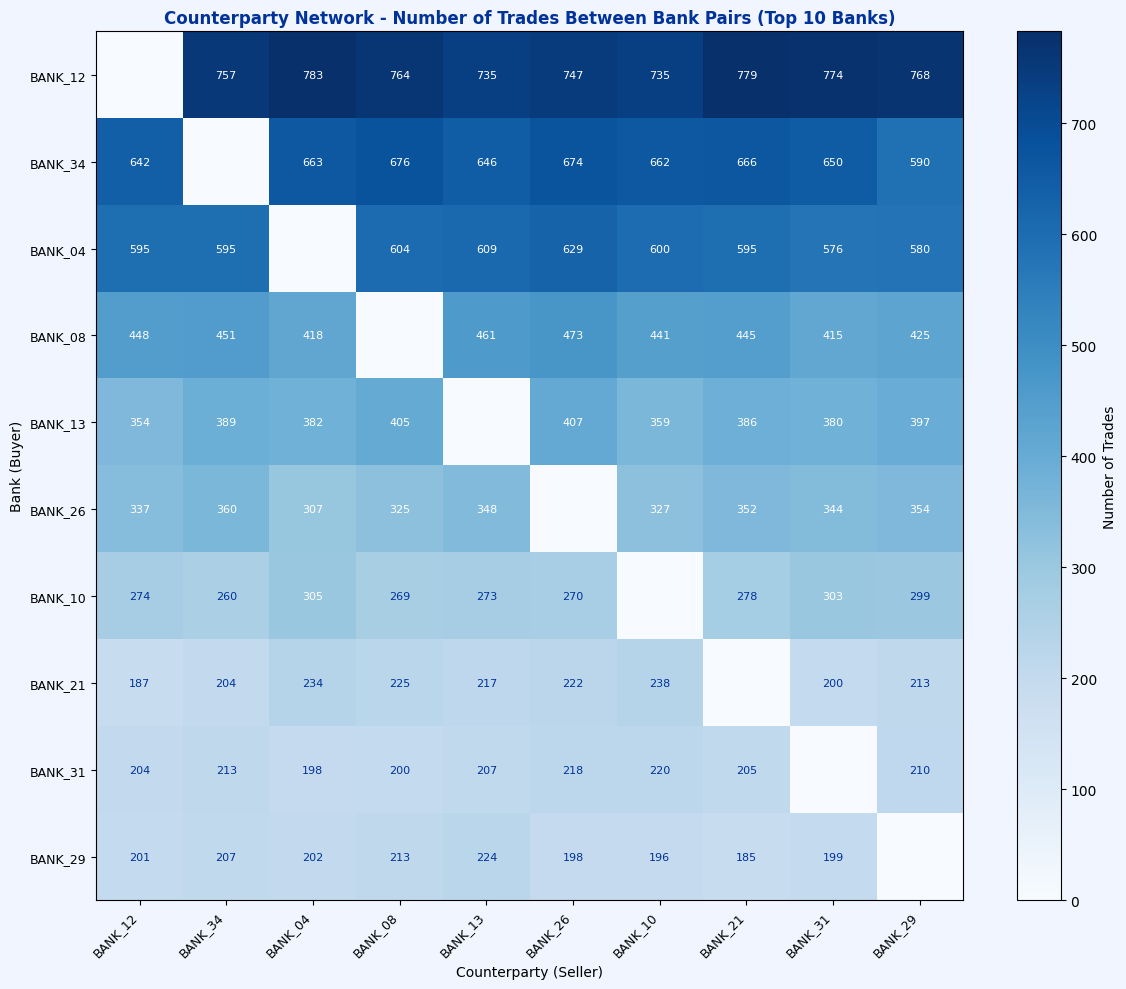

Chart saved: chart3_network.png


In [70]:
# Number of top banks to display in the network matrix
N_NETWORK_BANKS = 10 #change this value to show more or fewer banks

# Focus on top N most active banks (10 now for readability)
top_banks_network = (
    df_clean.groupby("BANK")["TRADE_ID"]
    .count()
    .nlargest(N_NETWORK_BANKS)
    .index.tolist()
)

# Filter for trades where both buyer AND seller are in the top N
df_network = df_clean[
    df_clean["BANK"].isin(top_banks_network) &
    df_clean["COUNTERPARTY"].isin(top_banks_network)
]

# Build network matrix: rows = buyer (BANK), cols = seller (COUNTERPARTY)
network_matrix = (
    df_network.groupby(["BANK", "COUNTERPARTY"])["TRADE_ID"]
    .count()
    .unstack(fill_value=0)
)

# Ensure both axes have the same banks in the same order (reindexing)
network_matrix = network_matrix.reindex(
    index=top_banks_network, columns=top_banks_network, fill_value=0
)

# Setting up the chart
fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(
    network_matrix.values,
    cmap="Blues",
    aspect="auto",
)

# Axis labels
ax.set_xticks(range(len(top_banks_network)))
ax.set_xticklabels(top_banks_network, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(top_banks_network)))
ax.set_yticklabels(top_banks_network, fontsize=9)

# Dynamic text colour: white on dark cells, ECB blue on light cells
vmin = network_matrix.values[network_matrix.values > 0].min()
vmax = network_matrix.values.max()
threshold = (vmax - vmin) / 2

for i in range(len(top_banks_network)):
    for j in range(len(top_banks_network)):
        val = network_matrix.values[i, j]
        if val > 0:
            text_color = "white" if val > threshold else ECB_BLUE
            ax.text(
                j, i, str(val),
                ha="center", va="center",
                fontsize=8, color=text_color,
            )

plt.colorbar(im, ax=ax, label="Number of Trades")
ax.set_title(f"Counterparty Network - Number of Trades Between Bank Pairs (Top {N_NETWORK_BANKS} Banks)")
ax.set_xlabel("Counterparty (Seller)", color=BLACK)
ax.set_ylabel("Bank (Buyer)", color=BLACK)

plt.tight_layout()
plt.savefig("chart3_network.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: chart3_network.png")

### Chart 4: Month-over-Month Change Heatmap - Top 10 Banks

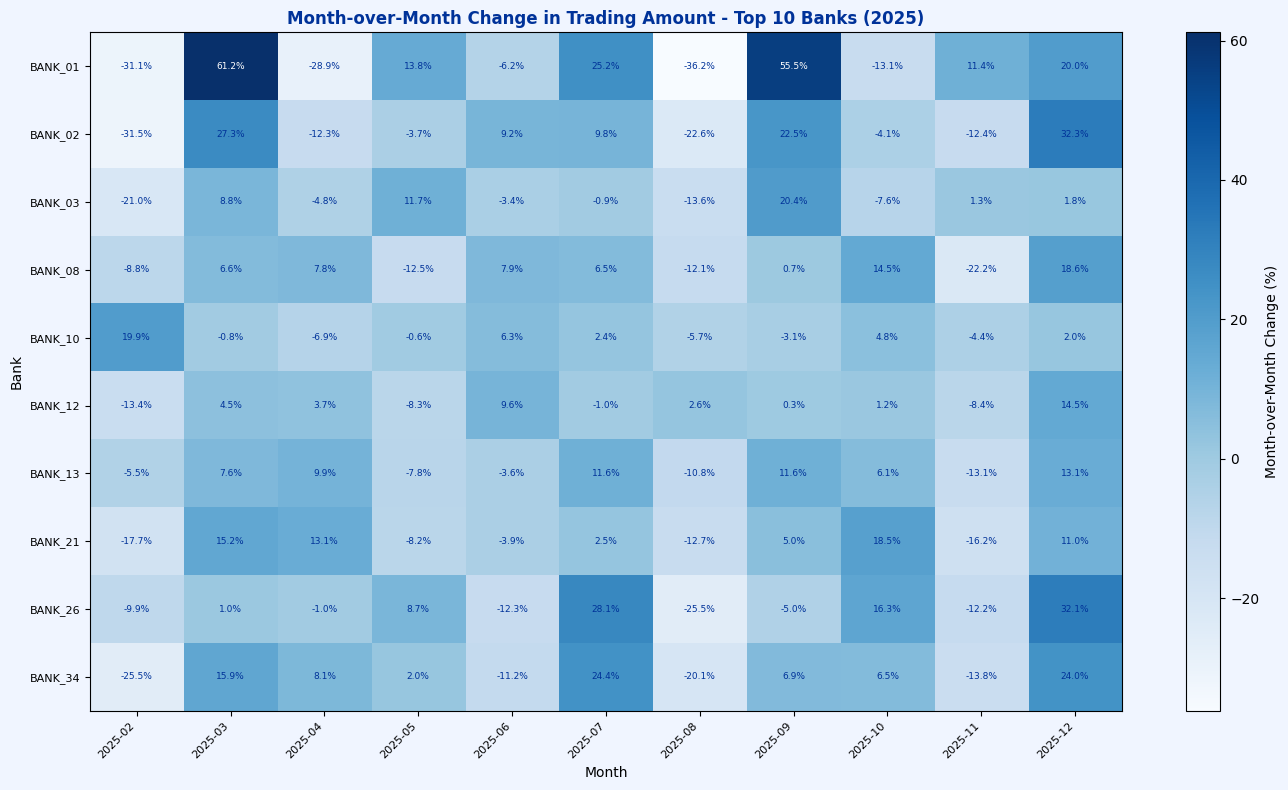

Chart saved: chart4_heatmap.png


In [71]:
# Number of top banks to display in the heatmap
N_HEATMAP_BANKS = 10 #change this value to show more or fewer banks

# Select the top N banks by total annual amount (10 now for readability)
top_banks_heatmap = (
    df_monthly.groupby("BANK")["TOTAL_AMOUNT_EUR"]
    .sum()
    .nlargest(N_HEATMAP_BANKS)
    .index.tolist()
)

# Pivot to banks x months matrix
heatmap_data = (
    df_monthly[df_monthly["BANK"].isin(top_banks_heatmap)]
    .pivot_table(
        index="BANK",
        columns="MONTH",
        values="MOM_CHANGE_PCT",
    )
)

# Convert period columns to readable strings
heatmap_data.columns = [str(c) for c in heatmap_data.columns]

fig, ax = plt.subplots(figsize=(14, 8))

im = ax.imshow(
    heatmap_data.values,
    cmap="Blues",
    aspect="auto",
)

# Axis labels
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index, fontsize=8)

# Dynamic text colour: hite on dark cells, ECB blue on light cells
vmin_h = np.nanmin(heatmap_data.values)
vmax_h = np.nanmax(heatmap_data.values)
threshold_h = (vmax_h - vmin_h) / 2

for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.values[i, j]
        if not np.isnan(val):
            text_color = "white" if val > threshold_h else ECB_BLUE
            ax.text(
                j, i, f"{val:.1f}%",
                ha="center", va="center",
                fontsize=6.5, color=text_color,
            )

plt.colorbar(im, ax=ax, label="Month-over-Month Change (%)")
ax.set_title(f"Month-over-Month Change in Trading Amount - Top {N_HEATMAP_BANKS} Banks (2025)")
ax.set_xlabel("Month", color=BLACK)
ax.set_ylabel("Bank", color=BLACK)

plt.tight_layout()
plt.savefig("chart4_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: chart4_heatmap.png")

## Section 5: Analysis

Key statistical insights from the compiled monthly dataset.

In [74]:
def print_analysis(df_monthly: pd.DataFrame, df_clean: pd.DataFrame) -> None:
    """
    Print key statistical insights from the compiled monthly dataset.

    Parameters
    ----------
    df_monthly : pd.DataFrame
        Monthly compiled dataset
    df_clean : pd.DataFrame
        Clean transaction-level dataset
    """
    print("-" * 55)
    print("  ANALYSIS SUMMARY")
    print("-" * 55)

    # Most and least active banks by total annual amount
    annual = df_monthly.groupby("BANK")["TOTAL_AMOUNT_EUR"].sum()
    print(f"Most active bank:            {annual.idxmax()} ({annual.max()/1e9:.2f}B EUR)")
    print(f"Least active bank:           {annual.idxmin()} ({annual.min()/1e9:.2f}B EUR)")
    print(f"Activity ratio (most/least): {annual.max()/annual.min():.1f}x")

    # Most concentrated bank (fewest avg counterparties)
    conc = df_monthly.groupby("BANK")["UNIQUE_COUNTERPARTIES"].mean()
    print(f"\nMost concentrated bank:  {conc.idxmin()} ({conc.min():.1f} avg counterparties/month)")
    print(f"Least concentrated bank: {conc.idxmax()} ({conc.max():.1f} avg counterparties/month)")

    # Most volatile bank (highest std dev of MoM change)
    vol = df_monthly.groupby("BANK")["MOM_CHANGE_PCT"].std().dropna()
    print(f"\nMost volatile bank:  {vol.idxmax()} (std dev: {vol.max():.1f}%)")
    print(f"Least volatile bank: {vol.idxmin()} (std dev: {vol.min():.1f}%)")

    # Most common top instrument type
    top_inst = df_monthly["TOP_INSTRUMENT_TYPE"].value_counts().idxmax()
    print(f"\nMost common top instrument type: {top_inst}")

    # Average MoM change across all banks
    avg_mom = df_monthly["MOM_CHANGE_PCT"].mean()
    print(f"Average MoM change across all banks: {avg_mom:.2f}%")

    # Most active trading pair — links to Chart 3
    pair_counts = (
        df_clean.groupby(["BANK", "COUNTERPARTY"])["TRADE_ID"]
        .count()
        .reset_index()
        .rename(columns={"TRADE_ID": "TRADE_COUNT"})
        .sort_values("TRADE_COUNT", ascending=False)
        .iloc[0]
    )
    print(f"\nMost active trading pair: {pair_counts['BANK']} -> {pair_counts['COUNTERPARTY']} ({pair_counts['TRADE_COUNT']:,} trades)")

    # Most active month — links to Chart 4
    monthly_total = (
        df_monthly.groupby("MONTH")["TOTAL_AMOUNT_EUR"]
        .sum()
    )
    best_month = monthly_total.idxmax()
    print(f"Most active month: {best_month} (total volume: {monthly_total.max()/1e9:.1f}B EUR)")

    print("-" * 55)


print_analysis(df_monthly, df_clean)

-------------------------------------------------------
  ANALYSIS SUMMARY
-------------------------------------------------------
Most active bank:            BANK_02 (4079.44B EUR)
Least active bank:           BANK_06 (0.79B EUR)
Activity ratio (most/least): 5182.8x

Most concentrated bank:  BANK_11 (10.2 avg counterparties/month)
Least concentrated bank: BANK_02 (33.0 avg counterparties/month)

Most volatile bank:  BANK_11 (std dev: 135.5%)
Least volatile bank: BANK_10 (std dev: 7.5%)

Most common top instrument type: TYPE_A
Average MoM change across all banks: 4.32%

Most active trading pair: BANK_12 -> BANK_28 (824 trades)
Most active month: 2025-01 (total volume: 1256.2B EUR)
-------------------------------------------------------
